# MMBSA_200 audit explorer — train + test

22 AF-ready train (MMBSA_75) + 26 AF-ready test (MMBSA_125). Bench iter 7, 2026-08-24.

Runs on CESGA via `juplaunch` (memory `[[reference_juplaunch]]`).

## Optional: connect to laptop PyMOL for spot-checks

On your **laptop** before running this notebook:
```bash
export PYMOL_PATH=/usr/lib/python3/dist-packages/pymol
pymol -R                            # RPC on :9123
ssh -R 9123:localhost:9123 ft3.cesga.es
```

On CESGA: `~/bin/juplaunch` → paste the URL into your laptop browser.
PyMOL connection is optional — the notebook works without it.


In [1]:
import os, json, glob, pathlib
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)


In [2]:
CSV_PATHS = ['$LUSTRE/MMBSA_200/generic_train_20260824_0848/artefacts/audit_report.csv', '$LUSTRE/MMBSA_200/generic_test_20260824_0848/artefacts/audit_report.csv']
CRYSTAL_ROOT = '/mnt/netapp1/Store_othcxlwa/FRUTON-NEW'
print('CSV_PATHS:', CSV_PATHS)
print('CRYSTAL_ROOT:', CRYSTAL_ROOT)

CSV_PATHS: ['$LUSTRE/MMBSA_200/generic_train_20260824_0848/artefacts/audit_report.csv', '$LUSTRE/MMBSA_200/generic_test_20260824_0848/artefacts/audit_report.csv']
CRYSTAL_ROOT: /mnt/netapp1/Store_othcxlwa/FRUTON-NEW


## Load audit CSV(s)

In [3]:
frames = []
p = os.path.expandvars("$LUSTRE/MMBSA_200/generic_train_20260824_0848/artefacts/audit_report.csv")
if pathlib.Path(p).is_file():
    df = pd.read_csv(p)
    df["split"] = "train"
    frames.append(df)
    print(f"loaded {len(df)} rows from train")
else:
    print(f"MISSING {p}  (bench dir absent — did the SLURM job finish?)")
p = os.path.expandvars("$LUSTRE/MMBSA_200/generic_test_20260824_0848/artefacts/audit_report.csv")
if pathlib.Path(p).is_file():
    df = pd.read_csv(p)
    df["split"] = "test"
    frames.append(df)
    print(f"loaded {len(df)} rows from test")
else:
    print(f"MISSING {p}  (bench dir absent — did the SLURM job finish?)")

df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"\nTOTAL rows: {len(df)}")
df.head()

loaded 22 rows from train
loaded 26 rows from test

TOTAL rows: 48


,pdb,overall_status,overall_confidence,model_written,n_gaps,delta_n,rolled_gaps,clash_pairs,omega_np,omega_cis_nonpro,rama_outliers,peptide_bonds_broken,gate_pass,refine_seconds,n_high,n_medium,n_low,n_failed,component_types,action_items,notes,error,split
0,1JCN,delivered_with_notes,medium,True,5,0,5,1,0,0,35,0,True,900.558642,1,4,0,0,cofactor;gap_fill,[gap_fill aggregate (5 gaps)] if the missing r...,NaN,NaN,train
1,1UOU,delivered_with_notes,medium,True,2,8,1,0,0,0,7,0,True,51.777533,1,3,0,0,cofactor;gap_fill,"[gap_fill aggregate (2 gaps, 1 rolled)] review...",NaN,NaN,train
2,2YCF,delivered_with_notes,medium,True,1,15,0,0,0,0,4,0,True,19.325682,4,4,0,0,cofactor;gap_fill;metal;protonation,[cofactor YCF A600] review the auto-generated ...,NaN,NaN,train
3,2Z3Y,delivered_with_notes,medium,True,2,8,1,0,0,0,14,0,True,204.755251,1,3,0,0,cofactor;gap_fill,"[gap_fill aggregate (2 gaps, 1 rolled)] review...",NaN,NaN,train
4,3S95,delivered_with_notes,medium,True,2,0,0,2,0,0,5,0,True,1.149787,20,5,0,0,cofactor;gap_fill;metal;protonation,[cofactor STU A1] review the auto-generated fr...,NaN,NaN,train


## Tier distribution

In [4]:
# Tier distribution per split
if len(df):
    tiers = df.groupby(["split", "overall_status"]).size().unstack(fill_value=0)
    tiers["total"] = tiers.sum(axis=1)
    for col in ("delivered_full_confidence", "delivered_with_notes",
                "delivered_needs_review", "not_delivered"):
        if col not in tiers.columns:
            tiers[col] = 0
    tiers["delivered_ok"] = tiers["delivered_full_confidence"] + tiers["delivered_with_notes"]
    tiers["ok_pct"] = (100 * tiers["delivered_ok"] / tiers["total"]).round(1)
    display(tiers[[
        "delivered_full_confidence", "delivered_with_notes",
        "delivered_needs_review", "not_delivered",
        "total", "delivered_ok", "ok_pct",
    ]])


overall_status,delivered_full_confidence,delivered_with_notes,delivered_needs_review,not_delivered,total,delivered_ok,ok_pct
split,,,,,,,
test,0,24,2,0,26,24,92.3
train,0,22,0,0,22,22,100.0


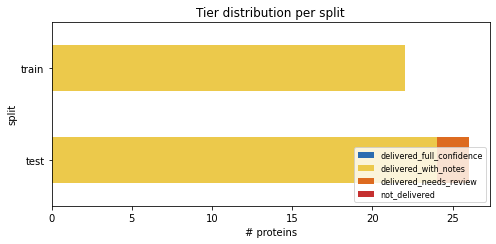

In [5]:
# Tier stacked bar
if len(df):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    tier_order = ["delivered_full_confidence", "delivered_with_notes",
                  "delivered_needs_review", "not_delivered"]
    colours = ["#2b6cb0", "#ecc94b", "#dd6b20", "#c53030"]
    grouped = df.groupby(["split", "overall_status"]).size().unstack(fill_value=0)
    for col in tier_order:
        if col not in grouped.columns:
            grouped[col] = 0
    grouped = grouped[tier_order]
    grouped.plot(kind="barh", stacked=True, color=colours, ax=ax, edgecolor="none")
    ax.set_xlabel("# proteins")
    ax.set_title("Tier distribution per split")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    plt.show()


## Needs-review triage

In [6]:
# Proteins flagged for manual review (with action items)
if len(df):
    nr = df[df["overall_status"] == "delivered_needs_review"]
    if len(nr):
        print(f"{len(nr)} protein(s) need manual review:")
        display(nr[["pdb", "split", "n_gaps", "delta_n", "clash_pairs",
                    "omega_np", "omega_cis_nonpro", "rama_outliers",
                    "gate_pass", "action_items", "notes"]])
    else:
        print("Zero proteins flagged for manual review in this set.")


2 protein(s) need manual review:


,pdb,split,n_gaps,delta_n,clash_pairs,omega_np,omega_cis_nonpro,rama_outliers,gate_pass,action_items,notes
43,7QUE,test,1,9,33,0,0,14,True,[gap_fill global quality vs crystal] inspect t...,NaN
46,8Q68,test,2,197,4,24,1,33,False,"[gap_fill aggregate (2 gaps, 1 rolled)] review...",cis-nonPro peptide bonds gained 1 (baseline 0 ...


## Delivered-with-notes glance-list

In [7]:
# Proteins delivered_with_notes — action items reviewers should glance at
if len(df):
    wn = df[df["overall_status"] == "delivered_with_notes"]
    if len(wn):
        print(f"{len(wn)} protein(s) delivered_with_notes:")
        # Show shortened action_items column so the row fits
        display(
            wn[["pdb", "split", "n_high", "n_medium", "n_low", "n_failed", "action_items"]]
              .rename(columns={"action_items": "action_items (glance)"})
        )
    else:
        print("Zero proteins with notes.")


46 protein(s) delivered_with_notes:


,pdb,split,n_high,n_medium,n_low,n_failed,action_items (glance)
0,1JCN,train,1,4,0,0,[gap_fill aggregate (5 gaps)] if the missing r...
1,1UOU,train,1,3,0,0,"[gap_fill aggregate (2 gaps, 1 rolled)] review..."
2,2YCF,train,4,4,0,0,[cofactor YCF A600] review the auto-generated ...
3,2Z3Y,train,1,3,0,0,"[gap_fill aggregate (2 gaps, 1 rolled)] review..."
4,3S95,train,20,5,0,0,[cofactor STU A1] review the auto-generated fr...
5,5GRN,train,5,2,0,0,[cofactor 748 A1001] review the auto-generated...
6,5HJS,train,3,4,0,0,[gap_fill aggregate (1 gaps)] if the missing r...
7,6KZD,train,3,2,0,0,[cofactor DZ6 A901] review the auto-generated ...
8,6NRH,train,9,2,0,0,[cofactor KYP A1101] review the auto-generated...
9,6O5I,train,8,4,0,0,"[gap_fill aggregate (3 gaps, 1 rolled)] review..."


## Component-type × confidence breakdown

In [8]:
# Component-type × confidence heatmap
# Requires re-reading the per-PDB JSONs (audit CSV aggregates but drops component detail).
def _load_components(csv_path: str) -> pd.DataFrame:
    art_dir = pathlib.Path(os.path.expandvars(csv_path)).parent
    rows = []
    for f in sorted(art_dir.glob("*.json")):
        if f.name.startswith("audit_") or f.name == "combined_results.json":
            continue
        try:
            d = json.loads(f.read_text())
        except Exception:
            continue
        pid = d.get("pdb", f.stem)
        for c in d.get("delivery", {}).get("components", []):
            rows.append({
                "pdb": pid,
                "component_type": c.get("component_type"),
                "confidence": c.get("confidence"),
                "method": c.get("method", ""),
                "reason": (c.get("reason") or "")[:120],
                "suggested_action": (c.get("suggested_action") or "")[:120],
            })
    return pd.DataFrame(rows)


comps_all = []
for p in CSV_PATHS:
    p = os.path.expandvars(p)
    cdf = _load_components(p)
    if len(cdf):
        cdf["source"] = pathlib.Path(p).parent.parent.name
        comps_all.append(cdf)

comps = pd.concat(comps_all, ignore_index=True) if comps_all else pd.DataFrame()
if len(comps):
    ct = comps.pivot_table(
        index="component_type", columns="confidence", aggfunc="size", fill_value=0,
    )
    for col in ("high", "medium", "low", "failed"):
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[["high", "medium", "low", "failed"]]
    ct["total"] = ct.sum(axis=1)
    print("Component × confidence breakdown:")
    display(ct)


Component × confidence breakdown:


confidence,high,medium,low,failed,total
component_type,,,,,
cofactor,126,118,0,0,244
gap_fill,67,75,2,0,144
metal,23,0,0,0,23
protonation,32,14,0,0,46


In [9]:
# Most common per-component method labels
if len(comps):
    method_counts = (
        comps.groupby(["component_type", "method"]).size()
             .reset_index(name="n")
             .sort_values("n", ascending=False)
             .head(30)
    )
    display(method_counts)


,component_type,method,n
0,cofactor,antechamber_gaff2,118
3,cofactor,strip_crystal,100
9,gap_fill,tleap_missing_expected_frcmod,48
11,protonation,metal_coord_geometry,43
6,gap_fill,check_model_quality,39
4,gap_fill,MODELLER_full,28
10,metal,LiMerz_12_6_4,23
2,cofactor,glycam,20
5,gap_fill,MODELLER_partial,14
7,gap_fill,check_model_quality_ref_bands,9


## Per-protein drill-down

In [10]:
# Per-protein drill-down: pick any PDB id from the audit table
PDB_ID = "8Q68"   # ← change me; e.g. one of the needs_review pdbs shown above

if len(df):
    row = df[df["pdb"] == PDB_ID]
    if not len(row):
        print(f"{PDB_ID} not in this bench set")
    else:
        print(f"=== {PDB_ID} ({row.iloc[0]['split']}) ===")
        for col in ("overall_status", "n_gaps", "delta_n", "rolled_gaps",
                    "clash_pairs", "omega_np", "omega_cis_nonpro", "rama_outliers",
                    "gate_pass", "action_items", "notes"):
            if col in row.columns:
                print(f"  {col:<20}: {row.iloc[0][col]}")
        # Component detail from JSON side-load
        if len(comps):
            pc = comps[comps["pdb"] == PDB_ID]
            if len(pc):
                print("\n  Components:")
                display(pc[["component_type", "confidence", "method", "reason", "suggested_action"]])


=== 8Q68 (test) ===
  overall_status      : delivered_needs_review
  n_gaps              : 2
  delta_n             : 197
  rolled_gaps         : 1
  clash_pairs         : 4
  omega_np            : 24
  omega_cis_nonpro    : 1
  rama_outliers       : 33
  gate_pass           : False
  action_items        : [gap_fill aggregate (2 gaps, 1 rolled)] review the 1 rolled-back windows in the pipeline log | [gap_fill global quality vs crystal] inspect the flagged residues in the pipeline log; 'above_p99' means the fill is worse than 99% of independently-deposited crystals — likely catastrophic splice or unresolvable geometry, consider manual refinement or REMARK 465 rollback | [cofactor K46 A501] review the auto-generated frcmod for K46: check partial charges (RESP vs AM1-BCC) and any missing dihedrals | [cofactor K46 B501] review the auto-generated frcmod for K46: check partial charges (RESP vs AM1-BCC) and any missing dihedrals | [gap_fill tleap loadability] supply the frcmod bundles listed i

,component_type,confidence,method,reason,suggested_action
373,gap_fill,medium,MODELLER_partial,1/2 gaps rolled back; 197 residues rescued,review the 1 rolled-back windows in the pipeli...
374,gap_fill,low,check_model_quality_ref_bands,regressed vs crystal baseline: clash +1 (band ...,inspect the flagged residues in the pipeline l...
375,cofactor,medium,antechamber_gaff2,'K46' is a non-canonical HETATM — antechamber ...,review the auto-generated frcmod for K46: chec...
376,cofactor,medium,antechamber_gaff2,'K46' is a non-canonical HETATM — antechamber ...,review the auto-generated frcmod for K46: chec...
377,gap_fill,medium,tleap_missing_expected_frcmod,tleap failed to load the model — EXPECTED beca...,supply the frcmod bundles listed in the per-co...


## Visual review — PyMOL windows

The following cells render into the **laptop PyMOL GUI** via the reverse tunnel (`-R 9123:localhost:9123`).  Skip if you only want the audit CSV analysis.

Provides three helpers:

- `show_gaps(pdb_id)` — crystal (grey) + FRUTON final (blue), gap-fill residues in red
- `show_active_site_protonation(pdb_id)` — final model, protonation colour-coded around metals
- `show_literature_reference(pdb_id)` — inline paper_evidence.md + lit image if present


In [11]:
# Connect to laptop PyMOL via reverse tunnel (localhost:9123)
# Requires: pymol -R running on laptop + ssh -R 9123:localhost:9123 to ft3
from pymol_remote.client import PymolSession
pm = PymolSession(hostname="localhost", port=9123, timeout=10.0)
print("PyMOL connected. Loaded objects:", pm.get_names())


ImportError: cannot import name 'cached_property' from 'functools' (/mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/lib/python3.7/functools.py)

In [12]:
# --- Visual review helpers -------------------------------------------------
# All functions render into the laptop PyMOL GUI via the reverse tunnel.
# Each helper reads the per-PDB JSON emitted by FRUTON's generic bench
# driver + the actual crystal/final PDB on disk.
import pathlib, json, os

def _pdb_json(pdb_id: str) -> dict:
    for csv_path in CSV_PATHS:
        art_dir = pathlib.Path(os.path.expandvars(csv_path)).parent
        f = art_dir / f"{pdb_id}.json"
        if f.is_file():
            return json.loads(f.read_text())
    return {}


def _crystal_path(pdb_id: str) -> pathlib.Path | None:
    p = pathlib.Path(CRYSTAL_ROOT) / pdb_id / f"{pdb_id}.pdb"
    return p if p.is_file() else None


def _final_pdb_path(pdb_id: str) -> pathlib.Path | None:
    # Bench driver stores per-protein artefact PDBs under artefacts dir
    for csv_path in CSV_PATHS:
        art_dir = pathlib.Path(os.path.expandvars(csv_path)).parent
        # Match either <pdb>_final.pdb (splice path) or the crystal itself
        # (BL-Pose fallback ships crystal-as-is).
        cand = list(art_dir.parent.rglob(f"{pdb_id}_final.pdb"))
        if cand: return cand[0]
    return _crystal_path(pdb_id)


def _gap_ranges_from_json(d: dict) -> list[tuple[str, int, int]]:
    # Try to recover per-gap boundaries from the per-PDB record.  The
    # current bench driver emits n_gaps + rolled_gaps at protein level
    # but not per-gap ranges; fall back to '(chain, resnum-1, resnum+1)'
    # around REMARK 465 residues in the crystal.
    ranges = []
    crystal = _crystal_path(d.get("pdb", ""))
    if crystal:
        current: tuple[str, int, int] | None = None
        for line in crystal.read_text(errors="replace").splitlines():
            if not line.startswith("REMARK 465"):
                continue
            parts = line.split()
            if len(parts) < 5: continue
            try:
                resnum = int(parts[-1])
                chain = parts[-2]
            except ValueError:
                continue
            if current is None:
                current = (chain, resnum, resnum)
            elif chain == current[0] and resnum == current[2] + 1:
                current = (chain, current[1], resnum)
            else:
                ranges.append(current)
                current = (chain, resnum, resnum)
        if current: ranges.append(current)
    return ranges


def show_gaps(pdb_id: str):
    """Load crystal (grey) + FRUTON final (blue), highlight gap residues red."""
    d = _pdb_json(pdb_id)
    crystal = _crystal_path(pdb_id)
    final = _final_pdb_path(pdb_id)
    pm.do("reinitialize")
    pm.do("bg_color white")
    if crystal:
        pm.do(f"load {crystal}, crystal")
        pm.do("color grey70, crystal"); pm.do("show cartoon, crystal")
    if final and final != crystal:
        pm.do(f"load {final}, final")
        pm.do("color skyblue, final"); pm.do("show cartoon, final")
    # Highlight gap-region residues in the final model
    for chain, lo, hi in _gap_ranges_from_json(d):
        sel = f"final and chain {chain} and resi {lo}-{hi}"
        pm.do(f"color red, {sel}")
        pm.do(f"show sticks, {sel} and not name C+N+O+CA")
    pm.do("zoom polymer")
    print(f"{pdb_id}: crystal={crystal.name if crystal else 'None'}, "
          f"final={final.name if final else 'None'}, "
          f"gap_ranges={_gap_ranges_from_json(d)}")


def show_active_site_protonation(pdb_id: str, cutoff: float = 5.0):
    """Colour residues around metals / active-site by their protonation state.

    HID orange, HIE yellow, HIP red, CYM green, CYS grey,
    ASH cyan (protonated Asp), GLH cyan (protonated Glu),
    TYM salmon (tyrosinate), LYN magenta (neutral Lys).
    """
    final = _final_pdb_path(pdb_id)
    if not final:
        print(f"no final pdb for {pdb_id}"); return
    pm.do("reinitialize"); pm.do("bg_color white")
    pm.do(f"load {final}, mdl")
    pm.do("color grey80, mdl"); pm.do("show cartoon, mdl")
    # Detect metal-containing HETATMs so we can zoom on the active site
    pm.do("show spheres, mdl and hetatm and elem Zn+Fe+Cu+Mg+Ca+Mn+Ni+Co+Mo")
    pm.do("color orange, mdl and resn HID")
    pm.do("color yellow, mdl and resn HIE")
    pm.do("color red,    mdl and resn HIP")
    pm.do("color green,  mdl and resn CYM")
    pm.do("color grey40, mdl and resn CYS")
    pm.do("color cyan,   mdl and resn ASH+GLH")
    pm.do("color salmon, mdl and resn TYM")
    pm.do("color magenta,mdl and resn LYN")
    # Sticks on any residue whose Cα is within cutoff of a metal
    pm.do(f"show sticks, mdl and byres (mdl and elem Zn+Fe+Cu+Mg+Ca+Mn+Ni+Co+Mo) around {cutoff}")
    pm.do("zoom mdl and elem Zn+Fe+Cu+Mg+Ca+Mn+Ni+Co+Mo, 10")
    print(f"{pdb_id}: shown active site with protonation colour code")
    print("   HID=orange, HIE=yellow, HIP=red, CYM=green, ASH/GLH=cyan, "
          "TYM=salmon, LYN=magenta")


def show_literature_reference(pdb_id: str):
    """If a paper_evidence.md or lit_image.png exists next to the crystal,
    display it inline in the notebook."""
    from IPython.display import display, Markdown, Image
    crystal = _crystal_path(pdb_id)
    if not crystal:
        print(f"no crystal for {pdb_id}"); return
    pdir = crystal.parent
    md = pdir / "paper_evidence.md"
    img = None
    for candidate in (pdir / "lit_image.png", pdir / "figure.png",
                      pdir / "paper_figure.png", pdir / "site.png"):
        if candidate.is_file():
            img = candidate; break
    if md.is_file():
        display(Markdown(f"### Paper evidence for {pdb_id}\n"))
        display(Markdown(md.read_text()))
    else:
        print(f"no paper_evidence.md for {pdb_id} (expected at {md})")
    if img:
        display(Markdown(f"### Literature image for {pdb_id}"))
        display(Image(str(img)))
    else:
        print(f"no lit image found for {pdb_id} in {pdir}")


print("Helpers loaded:")
print("  show_gaps(pdb_id)                       — crystal grey + final blue, gaps red")
print("  show_active_site_protonation(pdb_id)    — protonation colour code around metals")
print("  show_literature_reference(pdb_id)       — inline paper_evidence + lit image")


TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

### Demo: reproduced gaps in PyMOL

In [13]:
# Demo — change PDB_ID to any protein from the audit table.
# Requires PyMOL connection above.
DEMO_PDB = "8Q68"    # ← change me
try:
    show_gaps(DEMO_PDB)
except Exception as e:
    print(f"show_gaps failed: {e!r}")


show_gaps failed: NameError("name 'show_gaps' is not defined")


### Demo: active-site protonation colour-code

In [14]:
try:
    show_active_site_protonation(DEMO_PDB)
except Exception as e:
    print(f"show_active_site_protonation failed: {e!r}")


show_active_site_protonation failed: NameError("name 'show_active_site_protonation' is not defined")


### Demo: paper evidence + literature image (inline)

In [15]:
try:
    show_literature_reference(DEMO_PDB)
except Exception as e:
    print(f"show_literature_reference failed: {e!r}")


show_literature_reference failed: NameError("name 'show_literature_reference' is not defined")
